**LogiPredict:**

***Supply Chain Delay Diagnostic Engine Designed an automated EDA pipeline utilizing Pandas and statistical variance to identify historical freight bottlenecks, establishing the baseline for a predictive transit-delay model.***

<H4>PHASE-1 DATA INGESTION AND CLEANING</H4>

In [14]:
#Importing all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib

In [15]:
#Loading the Dataset-Source(Kaggle)
data_f = pd.read_csv("/Users/adityatripathi/Desktop/Supply_Chain/fmcg_sales_3years_1M_rows.csv")

In [16]:
#Looking at the data 
data_f.head(5)

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


In [20]:
#Analyzing the data's shape inorder to get an idea how huge is our data.
#Based on that we can intuitively approach to cleaning process.
data_f.shape

(1100000, 33)

In [17]:
#Assesing our data
#Trying to find all the null values in our dataframe
data_f.isna().sum()

date              0
year              0
month             0
day               0
weekofyear        0
weekday           0
is_weekend        0
is_holiday        0
temperature       0
rain_mm           0
store_id          0
country           0
city              0
channel           0
latitude          0
longitude         0
sku_id            0
sku_name          0
category          0
subcategory       0
brand             0
units_sold        0
list_price        0
discount_pct      0
promo_flag        0
gross_sales       0
net_sales         0
stock_on_hand     0
stock_out_flag    0
lead_time_days    0
supplier_id       0
purchase_cost     0
margin_pct        0
dtype: int64

In [25]:
#Checking the data types of each column so we can categorize and look for any bad values inside other than NaN
data_f.dtypes

date               object
year                int64
month               int64
day                 int64
weekofyear          int64
weekday             int64
is_weekend          int64
is_holiday          int64
temperature       float64
rain_mm           float64
store_id           object
country            object
city               object
channel            object
latitude          float64
longitude         float64
sku_id             object
sku_name           object
category           object
subcategory        object
brand              object
units_sold          int64
list_price        float64
discount_pct      float64
promo_flag          int64
gross_sales       float64
net_sales         float64
stock_on_hand       int64
stock_out_flag      int64
lead_time_days      int64
supplier_id        object
purchase_cost     float64
margin_pct        float64
dtype: object

In [27]:
#So we will now look into bad values first let's fix all the integer values 
x = data_f.describe().select_dtypes(['int64','float64'])

In [28]:
x.shape

(8, 22)

In [30]:
#Looking for particular which have inconsistencies like List_price can't be zero or negative.
#lead_time can't be negative

x.loc[['min','max','mean','std'],
      ['list_price','purchase_cost','lead_time_days']]

,list_price,purchase_cost,lead_time_days
min,1.080000,0.490000,1.000000
max,14.800000,11.100000,17.000000
mean,7.712100,4.625546,6.500404
std,4.253023,2.662604,2.014065


In [38]:
#Step - 1: The Target List- Extracting the column names from the filtered dataframe

# Dictionary comprehension to find unique values in object columns 
# ONLY if the column has less than 50 unique items (The Cardinality Shield)

hidden_nulls_check = {col: data_f[col].unique() for col in data_f.select_dtypes(['object']).columns if data_f[col].nunique() < 50}

# Print the result nicely
for column, unique_vals in hidden_nulls_check.items():
    print(f"--- {column} ---")
    print(unique_vals)
    print("\n")


--- store_id ---
['STORE0001' 'STORE0002' 'STORE0003' 'STORE0004' 'STORE0005' 'STORE0006'
 'STORE0007' 'STORE0008' 'STORE0009' 'STORE0010' 'STORE0011' 'STORE0012'
 'STORE0013']


--- country ---
['Germany' 'Italy' 'Poland' 'France' 'Spain' 'Austria' 'Netherlands']


--- city ---
['Berlin' 'Rome' 'Milan' 'Warsaw' 'Paris' 'Barcelona' 'Vienna' 'Madrid'
 'Amsterdam']


--- channel ---
['Hypermarket' 'Supermarket' 'E-commerce' 'Convenience']


--- category ---
['Personal Care' 'Beverages' 'Dairy' 'Snacks' 'Home Care']


--- subcategory ---
['Shampoo' 'Water' 'Yogurt' 'Chocolate' 'Soda' 'Detergent' 'Cheese'
 'Juice' 'Soap' 'Milk' 'Energy drink' 'Chips' 'Biscuits' 'Cleaner'
 'Softener' 'Nuts' 'Toothpaste']


--- brand ---
['BrandB' 'BrandD' 'BrandA' 'BrandF' 'BrandC' 'BrandE']




In [42]:
#Finding bad data in objects

import numpy as np 

bad_strings = [' ', '', '-', 'Unknown', 'N/A', 'null', 'NA']

data_f.replace(bad_strings, np.nan, inplace=True)

print(data_f.select_dtypes(['object']).isna().sum())

date           0
store_id       0
country        0
city           0
channel        0
sku_id         0
sku_name       0
category       0
subcategory    0
brand          0
supplier_id    0
dtype: int64


***This tells us that out data is incredibly clean which is usually not the case so be prepared for worse things.***

***Phase-2 Univariate Analysis***

In [37]:
# Grouping by supplier to calculate mean, standard deviation, and total order volume
supplier_risk = data_f.groupby('supplier_id')['lead_time_days'].agg(['mean', 'std', 'count'])

# Sorting by the highest standard deviation (most volatile/risky suppliers)
supplier_risk = supplier_risk.sort_values(by='std', ascending=False)

# Display the top 10 riskiest suppliers
print("Top 10 Most Volatile Suppliers:")
print(supplier_risk.head(10))

Top 10 Most Volatile Suppliers:
                 mean       std  count
supplier_id                           
S045         6.510940  2.031008  18464
S032         6.509712  2.029352  18277
S048         6.528638  2.028407  18315
S024         6.507716  2.027910  18469
S056         6.520824  2.025569  18344
S009         6.471900  2.025456  18345
S057         6.489768  2.025055  18423
S007         6.509875  2.024798  18481
S050         6.487104  2.024769  18222
S035         6.497406  2.024265  18116


In [56]:
x = data_f.select_dtypes(['int64','float64']).isna().sum()

year              0
month             0
day               0
weekofyear        0
weekday           0
is_weekend        0
is_holiday        0
temperature       0
rain_mm           0
latitude          0
longitude         0
units_sold        0
list_price        0
discount_pct      0
promo_flag        0
gross_sales       0
net_sales         0
stock_on_hand     0
stock_out_flag    0
lead_time_days    0
purchase_cost     0
margin_pct        0
dtype: int64

In [57]:
x.shape

(1100000, 22)

<AxesSubplot:xlabel='gross_sales', ylabel='Count'>

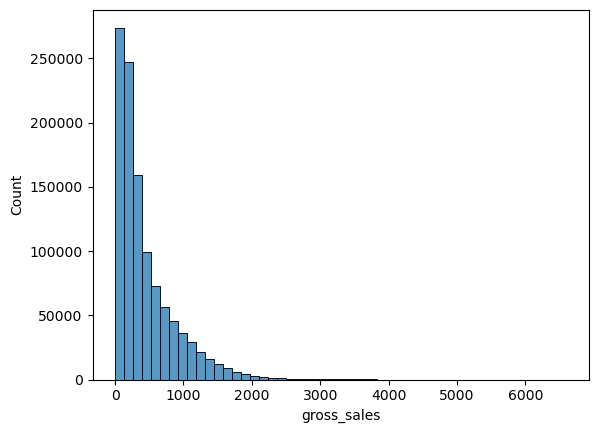

In [59]:
# We are looking on the numerical set for now 
#So, we will go with four major columns which makes some good set of insights
#Those are: gross_sales, units_sold, lead_time_days and stock_on_hand

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=data_f, x="gross_sales", bins=50)



***This is the graph which is right skewed which means most of the sales happened between 0 to 500 and very big orders like a B2B for example have gross_sales around 6000 dollars***

<AxesSubplot:xlabel='units_sold', ylabel='Count'>

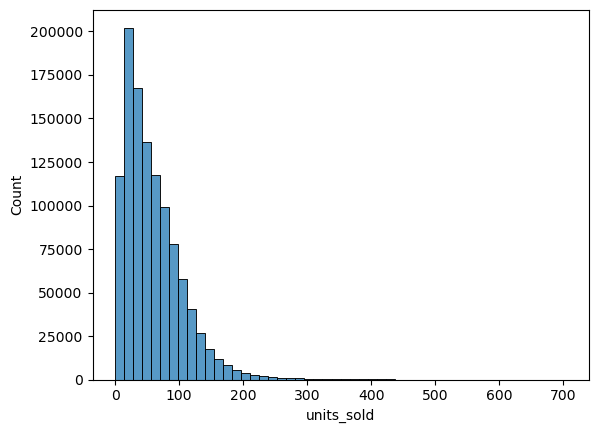

In [61]:
#Now checking for units_sold

sns.histplot(data=data_f, x="units_sold", bins =50)

***Same with this it is even same right skewed so same explanation for all of these graph. Now units_sold will be mostly under 0 to 100 for most of the common times but someone buying for a business will be much more and very rare.***

<AxesSubplot:xlabel='lead_time_days', ylabel='Count'>

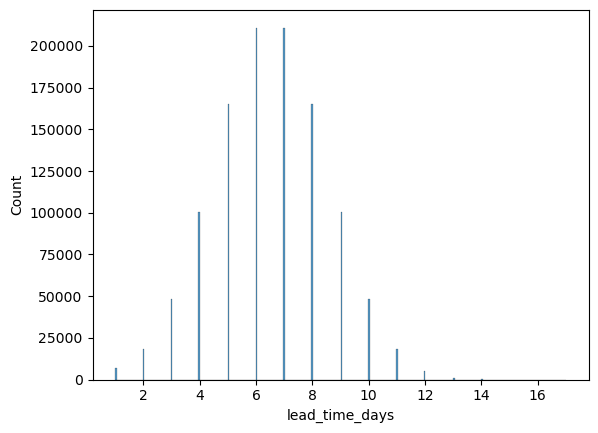

In [63]:
#Now checking for lead_time_days

sns.histplot(data=data_f, x="lead_time_days")

***If you look closely it is discrete data but almost forms a normal curve, so this just says that the most average time drivers take is between 6-8 days and some lazy drivers take 17 days.***

"The Reality: In standard organic data, you don't see \nperfectly spaced spikes like that. In supply chain \nanalytics, this usually means the company has a strict \nfixed reorder quantity. For example, they don't order \nexactly 283 units; they order standard pallets of 50 or \n100 at a time, which forces the inventory levels to pool around those nice, round numbers."

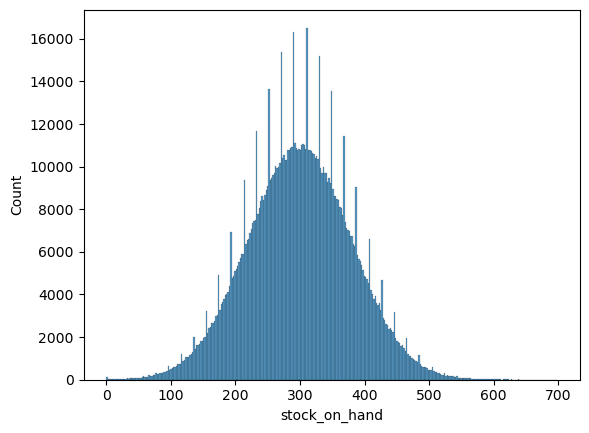

In [65]:
#Now checking for stock_on_hand

sns.histplot(data=data_f, x ="stock_on_hand")

#Graph looks like a bell shaped normal curve which it is but
'''The Reality: In standard organic data, you don't see 
perfectly spaced spikes like that. In supply chain 
analytics, this usually means the company has a strict 
fixed reorder quantity. For example, they don't order 
exactly 283 units; they order standard pallets of 50 or 
100 at a time, which forces the inventory levels to pool around those nice, round numbers.'''

***Univariate Analysis for Categorical Data***

<AxesSubplot:xlabel='channel', ylabel='count'>

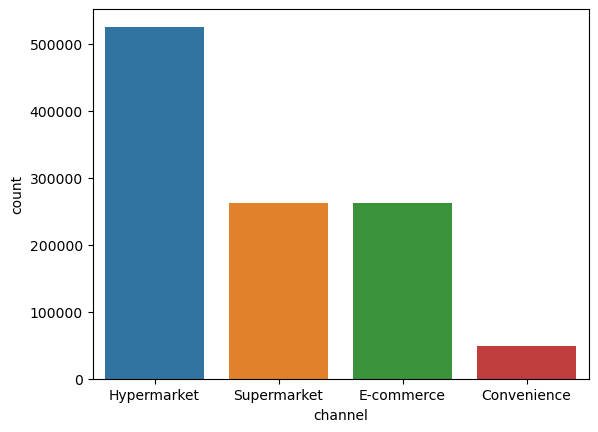

In [67]:
#First we will go from macro view of low cardinality to high 
#Our first choice is the channel like how is the each of them are 
#Impacting the business

sns.countplot(data=data_f, x = 'channel')

In [68]:
#After knowing which is working perfectly we will look
#which brand or category is making the sales the most

data_f['category'].value_counts().head(20)

Beverages        266085
Snacks           261705
Personal Care    199290
Dairy            196005
Home Care        176915
Name: category, dtype: int64

In [69]:
# We are looking that our data has one big supplier or 100+

data_f['supplier_id'].value_counts().head(20)

S037    18579
S051    18572
S041    18533
S040    18529
S020    18507
S019    18502
S007    18481
S060    18474
S028    18469
S024    18469
S044    18465
S045    18464
S042    18451
S004    18448
S012    18438
S034    18438
S005    18437
S001    18437
S017    18430
S057    18423
Name: supplier_id, dtype: int64

***Phase-3 Bivariate Analysis***

In [71]:
#We are going to compare the categorical group stock_out_flag with respect to lead_time_days
data_f.groupby(['stock_out_flag'])['lead_time_days'].mean()

stock_out_flag
0    6.500325
1    6.502929
Name: lead_time_days, dtype: float64

***As our intuition with supply chain analysis is generally considered to be that products go out of stock because the supplier takes too long to deliver them but this single group by output proves that out intuition is wrong. Lead time has absolutely nothing to do with whether an item goes out of stock. A supplier could deliver in 2 days or 15 days, and it statistically does not change the likelihood of the shelf going empty.***

In [72]:
#If it not lead time then it must be something else that must be draining the shelves. 
#Unit_solds are not causing stock outage
data_f.groupby(['stock_out_flag'])['units_sold'].mean()

stock_out_flag
0    60.670839
1    11.690312
Name: units_sold, dtype: float64

In [73]:
#promo_flag is not causing stock outage
data_f.groupby(['stock_out_flag'])['promo_flag'].mean()

stock_out_flag
0    0.080181
1    0.081929
Name: promo_flag, dtype: float64

In [78]:
#stock_on_hand is itself not causing stock outage
data_f.groupby(['stock_out_flag'])['stock_on_hand'].mean()

stock_out_flag
0    299.462723
1    299.892613
Name: stock_on_hand, dtype: float64

In [79]:
#Instead of taking numerical value we will take categorical value

data_f.groupby(['channel'])['stock_out_flag'].mean()

channel
Convenience    0.030369
E-commerce     0.030088
Hypermarket    0.030264
Supermarket    0.029749
Name: stock_out_flag, dtype: float64

In [81]:
#we did it by channel in above cell now by category it is still giving an average of 3% approximately so this is gem
#we need to test what's happening with time, thats are next step
data_f.groupby(['category'])['stock_out_flag'].mean()

category
Beverages        0.030272
Dairy            0.029724
Home Care        0.030020
Personal Care    0.029971
Snacks           0.030374
Name: stock_out_flag, dtype: float64

In [82]:
# Looking it with is_holiday or is_weekend 

data_f.groupby(['is_holiday'])['stock_out_flag'].mean()

is_holiday
0    0.030122
1    0.028803
Name: stock_out_flag, dtype: float64

In [83]:
data_f.groupby(['is_weekend'])['stock_out_flag'].mean()

is_weekend
0    0.030139
1    0.030016
Name: stock_out_flag, dtype: float64

In [92]:
#Building a correlation matrix heatmap to find out how is our data linked

corr_matrix = data_f.select_dtypes(['int64','float64']).corr()

<AxesSubplot:>

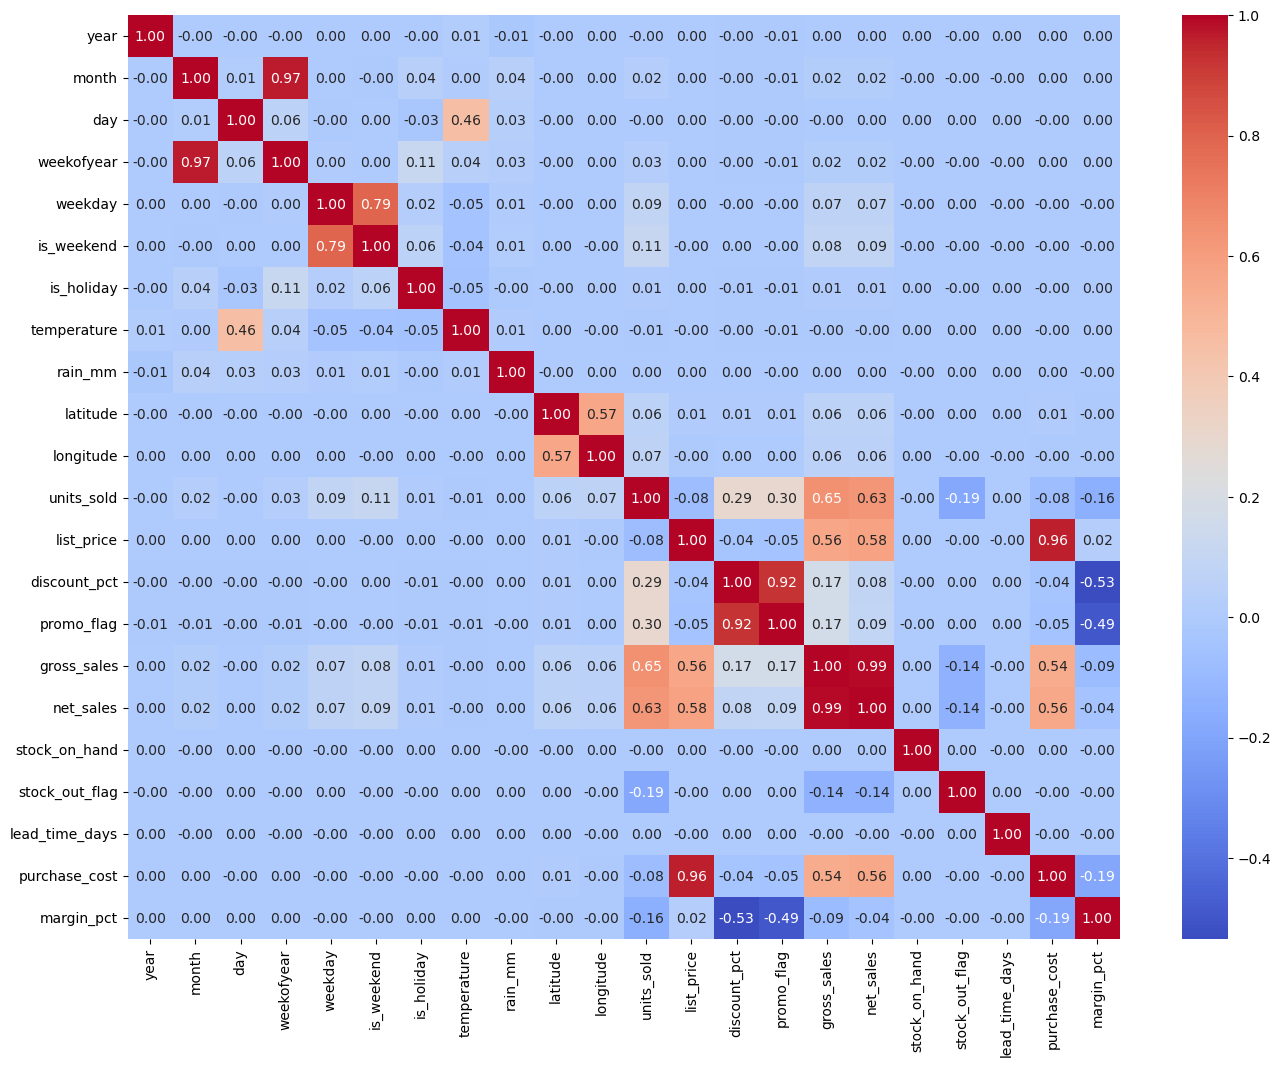

In [96]:
plt.figure(figsize=(16,12))
sns.heatmap(data=corr_matrix,annot=True, cmap='coolwarm',fmt='.2f')


***In this dataset, stockouts are entirely random. They are not caused by slow suppliers, holiday rushes, or poor inventory levels. Because this is Kaggle data, it is highly likely the creator of the dataset just wrote a script to randomly assign a "1" to 3% of the rows to stimulate stockouts, rather than building real causal logic into the numbers.***

***Phase-4 Predictive Model: We will use one of our numerical oriented predictive ML algorithm regression for our prediction of unit_solds. Firstly, we have come to a conclusion that our unit_solds is highly correlated with gross_sales, net_sales, discount_pct and promo_flags. Here, is the twist as we know the gross_sales and net_sales usually tells us how many units are sold by seeing so this is totally useful for us. So, we look for our other two options. Before, doing so we will split our data into train/test datasets.***

In [97]:
#The Features(Inputs)
X = data_f[['promo_flag', 'discount_pct']]

#The Target(Output)
y = data_f['units_sold']

In [99]:
#We need to import the specific tool that shuffle and chops the data.
from sklearn.model_selection import train_test_split

#We set test_size = 0.2 to explicitly enforce the 80/20 split, and we use random shuffle 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [107]:
#Having regression model to predict we will first train and then test

from sklearn.linear_model import LinearRegression, Ridge

model_train = LinearRegression()
ridge_model = Ridge(alpha=0.5)



In [108]:
model_train.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

Ridge(alpha=0.5)

In [111]:
print("Weights with regression model:",model_train.coef_)
print("Weights with ridge model:", ridge_model.coef_)

Weights with regression model: [ 28.58275714 109.3469439 ]
Weights with ridge model: [ 28.60788408 109.21102111]


In [112]:
model_train.predict(X_test)

array([55.24790467, 55.24790467, 55.24790467, ..., 55.24790467,
       55.24790467, 55.24790467])

In [114]:
ridge_model.predict(X_test)

array([55.24792234, 55.24792234, 55.24792234, ..., 55.24792234,
       55.24792234, 55.24792234])

In [115]:
#Grading the model predictions
#1. Import the grading metrics
from sklearn.metrics import mean_absolute_error, r2_score

#Save your model's predictions to a variable
predictions = model_train.predict(X_test)

#Calculate Mean Absolute Error(MAE)
mae = mean_absolute_error(y_test, predictions)

#Calculating R-Squared (R2)
r2 = r2_score(y_test, predictions)

# Print the final report

print(f"Mean Absolute Error(MAE): {mae: .2f} units")
print(f"R-Squared (R2): {r2:.4f}")


Mean Absolute Error(MAE):  33.36 units
R-Squared (R2): 0.0896


***So, what actually our model is saying- When we use this model to predict how much inventory we will sell tomorrow, we are usually off by about 33.36 units. The R-Squared is relatively low around 8-9% which means our promotions and discounts account for roughly 9% of the reason our sales fluctuate. The other 91$ is caused by factors outside of these two columns.***